# ResNet-50 Model for Retinal OCT Disease Classification

This notebook implements a ResNet-50 deep learning model for multiclass classification of retinal OCT images from the Kermany2018 dataset.

The model is trained to classify images into four categories: CNV, DME, DRUSEN, and NORMAL. ResNet-50 is used as the baseline convolutional neural network because of its residual connections, stability, and strong performance in image classification tasks.

The experiment uses transfer learning with ImageNet pretrained weights, image resizing to 224×224 pixels, data augmentation, early stopping, model checkpointing, and performance evaluation using accuracy, precision, recall, F1-score, Macro F1-score, and a confusion matrix.

In [4]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

print("TensorFlow version:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
DATA_DIR = "/kaggle/input/datasets/fabrizioravelli/retinal-oct-images-splitted"

train_dir = os.path.join(DATA_DIR, "training", "train")
val_dir = os.path.join(DATA_DIR, "training", "val")
test_dir = os.path.join(DATA_DIR, "test")

print("Train existe:", os.path.exists(train_dir))
print("Val existe:", os.path.exists(val_dir))
print("Test existe:", os.path.exists(test_dir))

print("Clases:", os.listdir(train_dir))

Train existe: True
Val existe: True
Test existe: True
Clases: ['DRUSEN', 'CNV', 'NORMAL', 'DME']


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 20

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Clases detectadas:", class_names)
print("Número de clases:", NUM_CLASSES)

Found 61284 files belonging to 4 classes.
Found 7659 files belonging to 4 classes.
Found 7664 files belonging to 4 classes.
Clases detectadas: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Número de clases: 4


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [10]:
small_train_ds = train_ds.take(20)
small_val_ds = val_ds.take(5)

print("Small train batches:", len(list(small_train_ds)))
print("Small val batches:", len(list(small_val_ds)))

Small train batches: 20
Small val batches: 5


In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")

In [12]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

resnet50_model = models.Model(inputs, outputs, name="ResNet50_Kermany2018")

resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

resnet50_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_Kermany2018"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │      8,196 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [13]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="resnet50_best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger("resnet50_training_log.csv")
]

In [14]:
start_time = time.time()

history_small = resnet50_model.fit(
    small_train_ds,
    validation_data=small_val_ds,
    epochs=3,
    callbacks=callbacks
)

end_time = time.time()
small_training_time = end_time - start_time

print(f"Tiempo de prueba rápida: {small_training_time:.2f} segundos")

Epoch 1/3


I0000 00:00:1780023705.389617     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.2974 - loss: 1.7831
Epoch 1: val_loss improved from None to 0.76273, saving model to resnet50_best_model.keras

Epoch 1: finished saving model to resnet50_best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 345ms/step - accuracy: 0.3203 - loss: 1.6913 - val_accuracy: 0.6250 - val_loss: 0.7627
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.3380 - loss: 1.5477
Epoch 2: val_loss improved from 0.76273 to 0.60072, saving model to resnet50_best_model.keras

Epoch 2: finished saving model to resnet50_best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 222ms/step - accuracy: 0.3641 - loss: 1.5181 - val_accuracy: 0.7250 - val_loss: 0.6007
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.3992 - loss: 1.4006
Epoch 3: val_loss improved from 0.60072 to 0.50470, saving model to resnet50_best_model.keras

Epoch 3: finished saving model to resnet50_best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 222ms/step - accuracy: 0.418

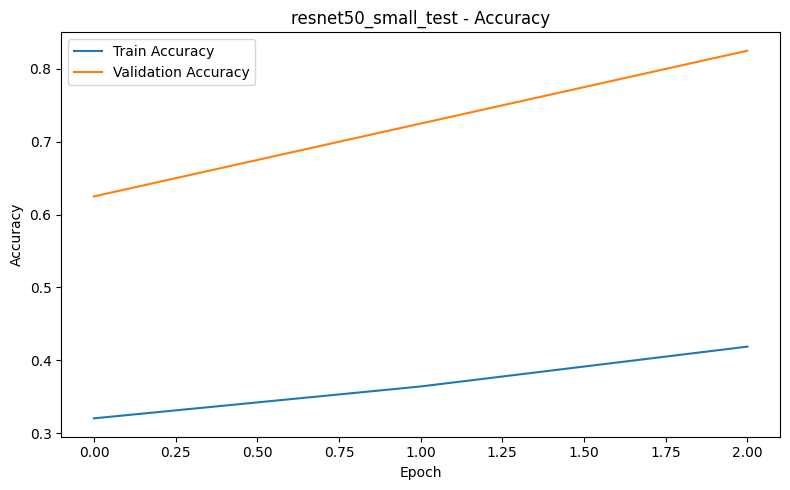

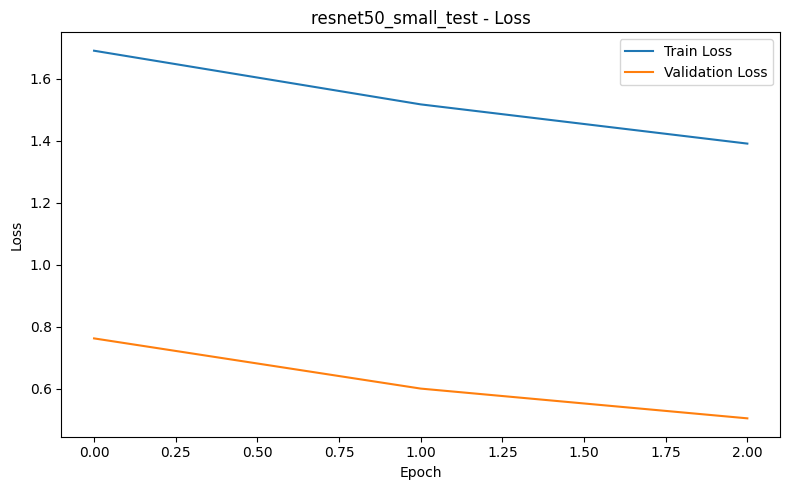

In [15]:
def plot_training_curves(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_accuracy_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_loss_curve.png", dpi=300)
    plt.show()

plot_training_curves(history_small, "resnet50_small_test")

## Training

In [16]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

resnet50_model = models.Model(inputs, outputs, name="ResNet50_Kermany2018")

resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="resnet50_best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger("resnet50_training_log.csv")
]

In [18]:
start_time = time.time()

history = resnet50_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

end_time = time.time()
training_time = end_time - start_time

print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time/60:.2f} minutos")

Epoch 1/20
1916/1916 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6464 - loss: 0.9350
Epoch 1: val_loss improved from None to 0.55114, saving model to resnet50_best_model.keras

Epoch 1: finished saving model to resnet50_best_model.keras
1916/1916 ━━━━━━━━━━━━━━━━━━━━ 292s 149ms/step - accuracy: 0.7127 - loss: 0.7686 - val_accuracy: 0.8039 - val_loss: 0.5511
Epoch 2/20
1915/1916 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7854 - loss: 0.5845
Epoch 2: val_loss improved from 0.55114 to 0.50708, saving model to resnet50_best_model.keras

Epoch 2: finished saving model to resnet50_best_model.keras
1916/1916 ━━━━━━━━━━━━━━━━━━━━ 283s 148ms/step - accuracy: 0.7933 - loss: 0.5634 - val_accuracy: 0.8184 - val_loss: 0.5071
Epoch 3/20
1915/1916 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8092 - loss: 0.5236
Epoch 3: val_loss improved from 0.50708 to 0.47483, saving model to resnet50_best_model.keras

Epoch 3: finished saving model to resnet50_best_model.keras
1916/1916 ━━━━━━━━━━━━

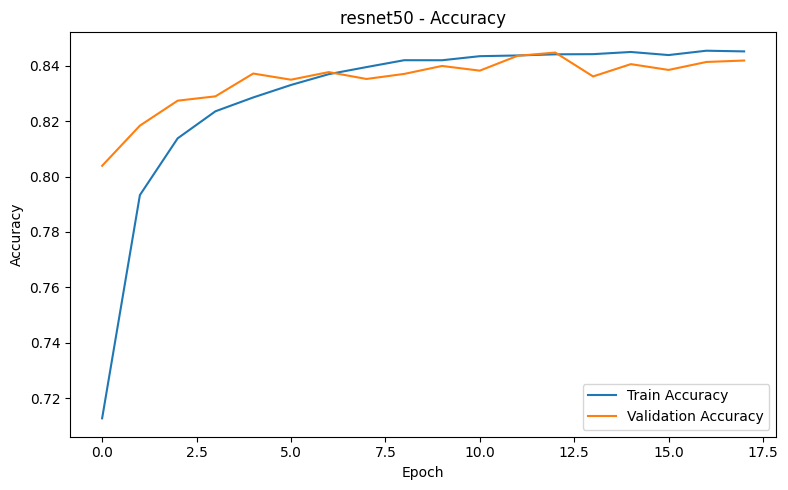

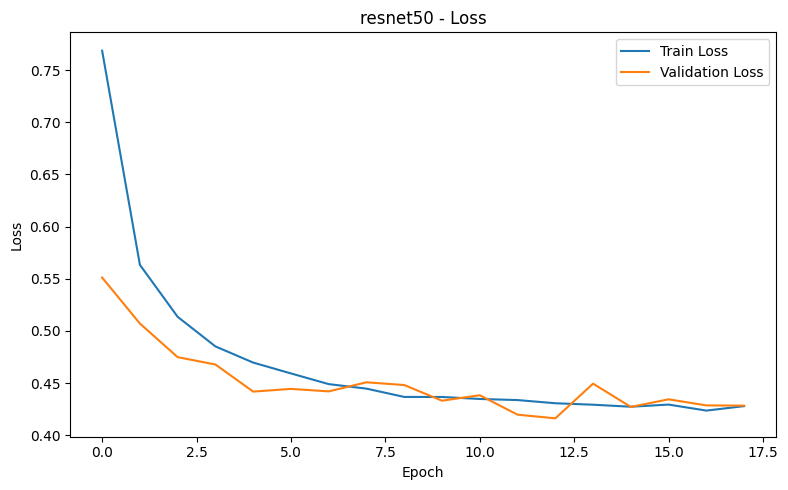

In [19]:
plot_training_curves(history, "resnet50")

In [20]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = resnet50_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

### Classification Report

In [21]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report.to_csv("resnet50_classification_report.csv")

df_report

,precision,recall,f1-score,support
CNV,0.847218,0.967141,0.903216,3165.000000
DME,0.932679,0.605096,0.733996,1099.000000
DRUSEN,0.846512,0.232439,0.364729,783.000000
NORMAL,0.823887,0.983187,0.896516,2617.000000
accuracy,0.845642,0.845642,0.845642,0.845642
macro avg,0.862574,0.696966,0.724614,7664.000000
weighted avg,0.851434,0.845642,0.821647,7664.000000


In [22]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         CNV       0.85      0.97      0.90      3165
         DME       0.93      0.61      0.73      1099
      DRUSEN       0.85      0.23      0.36       783
      NORMAL       0.82      0.98      0.90      2617

    accuracy                           0.85      7664
   macro avg       0.86      0.70      0.72      7664
weighted avg       0.85      0.85      0.82      7664



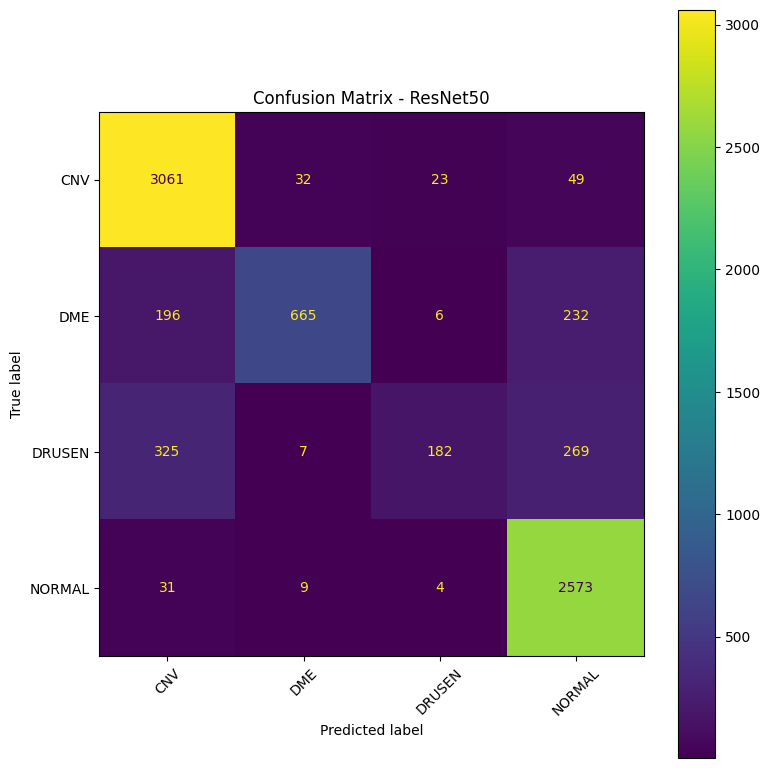

In [23]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - ResNet50")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("resnet50_confusion_matrix.png", dpi=300)
plt.show()

In [24]:
metrics = {
    "model": "ResNet50",
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(y_true, y_pred, average="macro"),
    "recall_macro": recall_score(y_true, y_pred, average="macro"),
    "f1_macro": f1_score(y_true, y_pred, average="macro"),
    "precision_weighted": precision_score(y_true, y_pred, average="weighted"),
    "recall_weighted": recall_score(y_true, y_pred, average="weighted"),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    "training_time_seconds": training_time,
    "training_time_minutes": training_time / 60,
    "epochs_trained": len(history.history["loss"])
}

df_metrics = pd.DataFrame([metrics])
df_metrics.to_csv("resnet50_metrics_summary.csv", index=False)

df_metrics

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,training_time_seconds,training_time_minutes,epochs_trained
0,ResNet50,0.845642,0.862574,0.696966,0.724614,0.851434,0.845642,0.821647,5095.554561,84.925909,18


In [25]:
total_params = resnet50_model.count_params()

trainable_params = np.sum([
    np.prod(v.shape) for v in resnet50_model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(v.shape) for v in resnet50_model.non_trainable_weights
])

params_summary = pd.DataFrame([{
    "model": "ResNet50",
    "total_params": total_params,
    "trainable_params": trainable_params,
    "non_trainable_params": non_trainable_params
}])

params_summary.to_csv("resnet50_params_summary.csv", index=False)
params_summary

,model,total_params,trainable_params,non_trainable_params
0,ResNet50,23595908,8196,23587712


## Preliminary Conclusion

ResNet-50 was implemented as the baseline convolutional neural network for retinal OCT disease classification. The model used transfer learning with ImageNet pretrained weights and was trained using early stopping and model checkpointing.

The evaluation includes accuracy, precision, recall, F1-score, Macro F1-score, and a confusion matrix. These metrics are necessary because the dataset presents class imbalance, especially in clinically relevant minority classes such as DME and DRUSEN.

The results obtained from this baseline model will be compared later against EfficientNet-B3 and Vision Transformer to analyze trade-offs in predictive performance, computational cost, convergence behavior, and interpretability.